# Parser debug plots

Quick visual check that the field-profile parsers and the layer segmentation behave. `weac.parser.plotting.plot_force_penetration_parser` runs a parser and lays out four depth-aligned panels:

1. **Penetration force** vs plumb depth (as the probe records it).
2. **Sample density** vs plumb depth (derived via the chosen model).
3. **Sample density** vs slope-normal depth (plumb depth compressed by `cos(phi)`).
4. **Segmented layers** (`bin` or `gradient`) vs slope-normal depth, with the slope-normal density faintly overlaid so you can eyeball whether the layering tracked the signal.

Panels 1-2 are plumb; panels 3-4 are slope-normal (WEAC's `Layer.h` convention), so the staircase lines up with the slope-normal density. The same plotting code serves both parsers because their profiles share the `depth_mm` / `penetration_resistance_kPa` / `density_kg_m3` fields.

Both sample profiles in `demo/data/` are a **co-located pair** from Weissfluhjoch on 2025-12-15: the SnowMicroPen `.PNT` and the SnowScope `.csv` were taken the same morning ~4 m apart, so their profiles are directly comparable.

In [ ]:
%matplotlib inline
from pathlib import Path

import numpy as np

from weac.parser import SMPParser, SnowPilotParser, SnowScopeParser
from weac.parser.plotting import (
    plot_force_penetration_layers,
    plot_force_penetration_parser,
    plot_snowscope_penetration_parser,
)

DATA = Path("data") if Path("data").exists() else Path("demo") / "data"
PNT = DATA / "S36N2470.PNT"
CSV = DATA / "Profile671_SN00353.csv"
PNT, CSV


(PosixPath('data/S36N2470.PNT'), PosixPath('data/Profile671_SN00353.csv'))

# SnowMicroPen (`.PNT`)

`CR2020` (Calonne & Richter 2020) is the most robust parameterization on this file; `P2015` / `K2020b` can dip negative in noisy windows. Surface and ground are auto-detected at construction.

In [ ]:
smp = SMPParser(str(PNT), density_method="CR2020")
smp_profile = smp.extract_profile()
print("coordinates :", smp_profile.coordinates)
print("samples     :", smp_profile.depth_mm.size)
print(
    "depth (mm)  : %.1f -> %.1f" % (smp_profile.depth_mm[0], smp_profile.depth_mm[-1])
)
print(
    "force (kPa) : %.1f - %.1f"
    % (smp_profile.penetration_resistance_kPa.min(), smp_profile.penetration_resistance_kPa.max())
)
print(
    "density     : %.1f - %.1f kg/m3"
    % (smp_profile.density_kg_m3.min(), smp_profile.density_kg_m3.max())
)

coordinates : (46.82966613769531, 9.809202194213867)
samples     : 1344
depth (mm)  : 0.0 -> 671.5
force (kPa) : 4.1 - 1132.5
density     : 144.5 - 463.3 kg/m3


## Bin segmentation (fixed thickness)

One call debug view. `bin` groups samples into ~`layer_thickness_mm` slabs (here 20 mm).

SMP bin 20 mm -> 34 layers


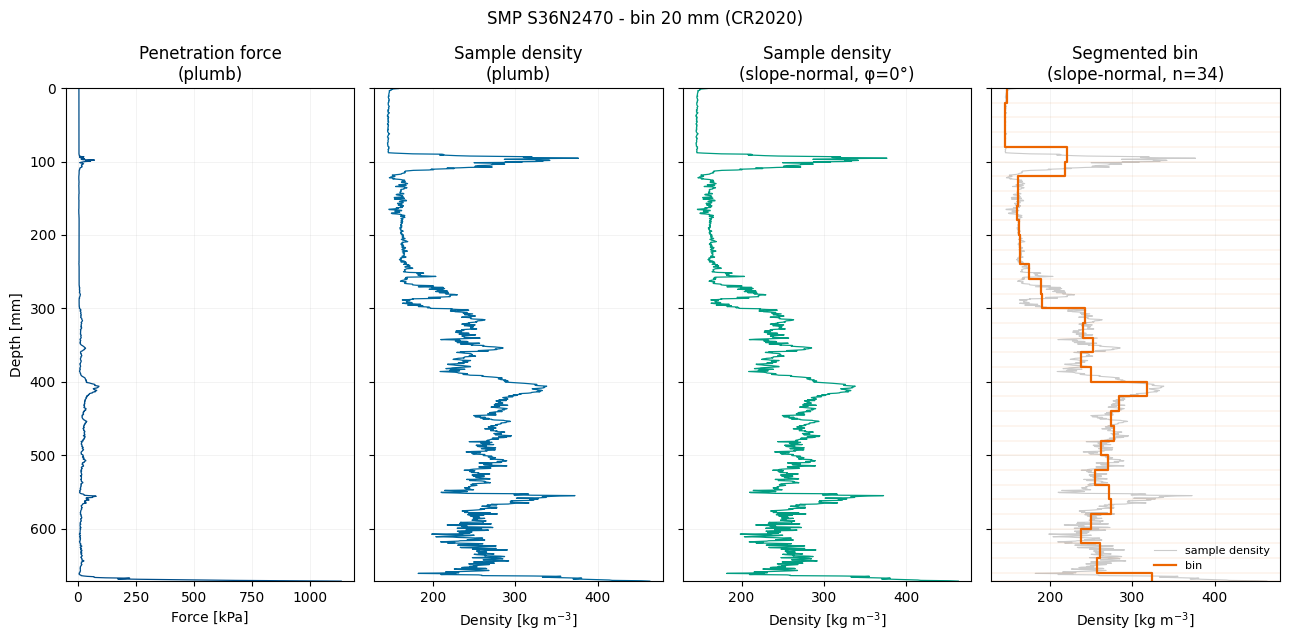

In [4]:
smp_bin, _ = smp.extract_layers(method="bin", layer_thickness_mm=20.0)
print(f"SMP bin 20 mm -> {len(smp_bin)} layers")
fig = plot_force_penetration_parser(
    smp,
    method="bin",
    layer_thickness_mm=20.0,
    title="SMP S36N2470 - bin 20 mm (CR2020)",
    show=False,
)

## Gradient segmentation

`gradient` cuts a new layer wherever `|drho/dz|` over a fixed 2.5 mm span exceeds the threshold (kg/m3/mm), so ramps become a staircase and quiet stretches collapse into one layer.

SMP gradient T=12 -> 82 layers


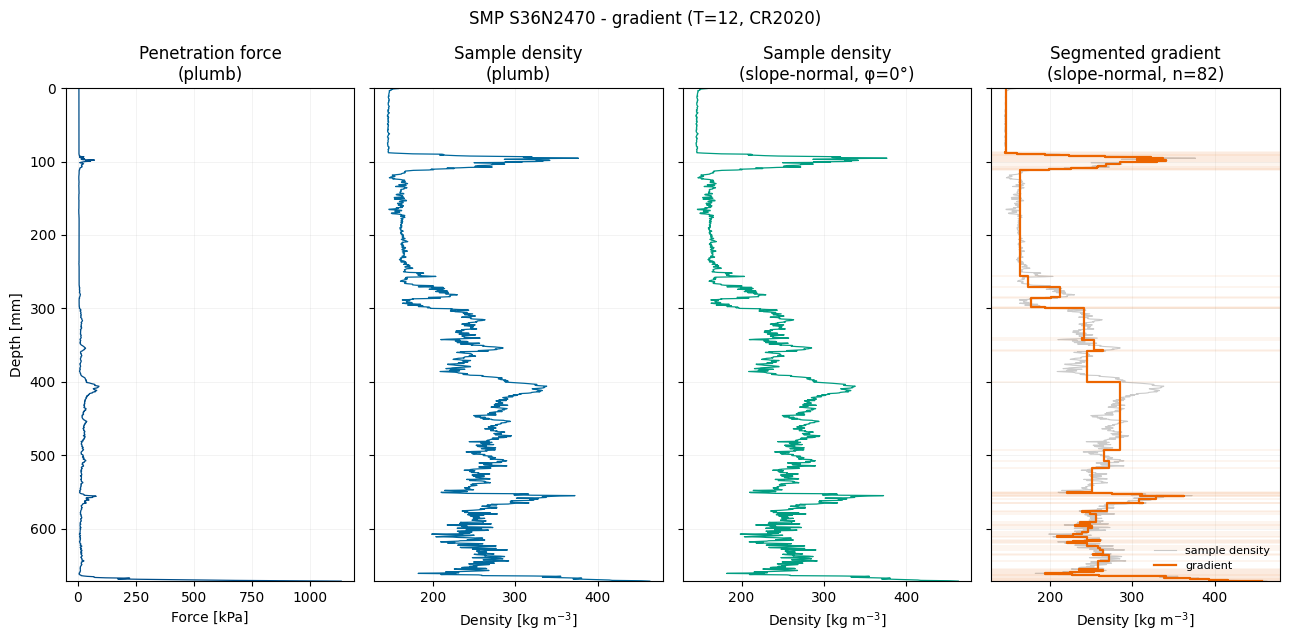

In [5]:
scope_grad, _ = scope.extract_layers(method="gradient", gradient_threshold=12.0)
print(f"SnowScope gradient T=12 -> {len(scope_grad)} layers")
fig = plot_force_penetration_parser(
    scope,
    method="gradient",
    gradient_threshold=12.0,
    title="SnowScope Profile671 - gradient (T=12)",
    show=False,
)


In [ ]:
fig = plot_snowscope_penetration_parser(
    scope,
    method="bin",
    layer_thickness_mm=20.0,
    semilog_slope=55.0,
    semilog_intercept=40.0,
    title="SnowScope Profile671 - bin 20 mm (custom semilog)",
    show=False,
)


## Slope-normal effect

Passing a non-zero `slope_angle_deg` scales `Layer.h` (and the slope-normal panels) by `cos(phi)`. Panels 1-2 stay plumb; panels 3-4 compress, and the staircase still tracks the slope-normal density. The layer *count* is unchanged - only the thicknesses scale.

SMP bin 20 mm @ 35 deg -> 34 layers


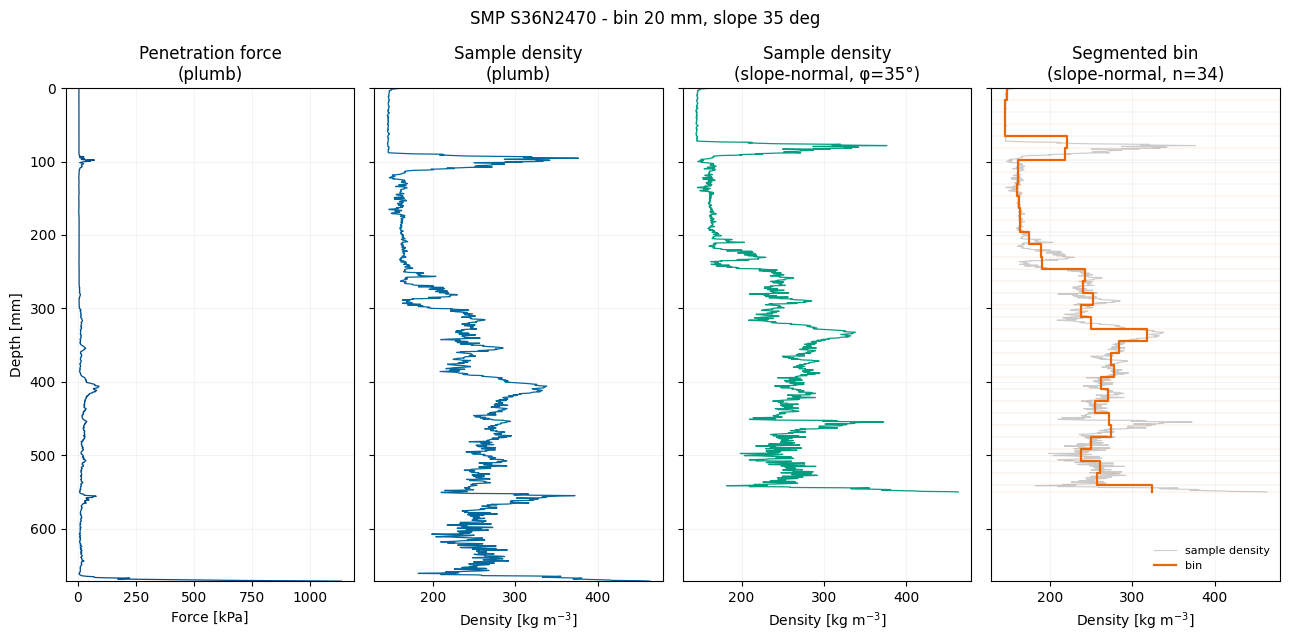

In [6]:
smp_slope, _ = smp.extract_layers(35.0, method="bin", layer_thickness_mm=20.0)
print(f"SMP bin 20 mm @ 35 deg -> {len(smp_slope)} layers")
fig = plot_force_penetration_parser(
    smp,
    method="bin",
    layer_thickness_mm=20.0,
    slope_angle_deg=35.0,
    title="SMP S36N2470 - bin 20 mm, slope 35 deg",
    show=False,
)

## Force offset (drift correction)

The SMP force signal carries a small baseline drift. Passing `apply_drift_correction=True` at construction calls snowmicropyn's `subtract_force_offset()`, which subtracts a near-constant offset (~3 kPa here) from the whole profile. It barely moves the strong sub-surface signal but noticeably lifts the weak near-surface force off the baseline, so it mainly matters when the low-force detail (and the density derived from it) is of interest. Below we overlay the raw and offset-corrected force on the same depth axis.

Surface at:  43.0
median subtracted offset: 3.35 kPa


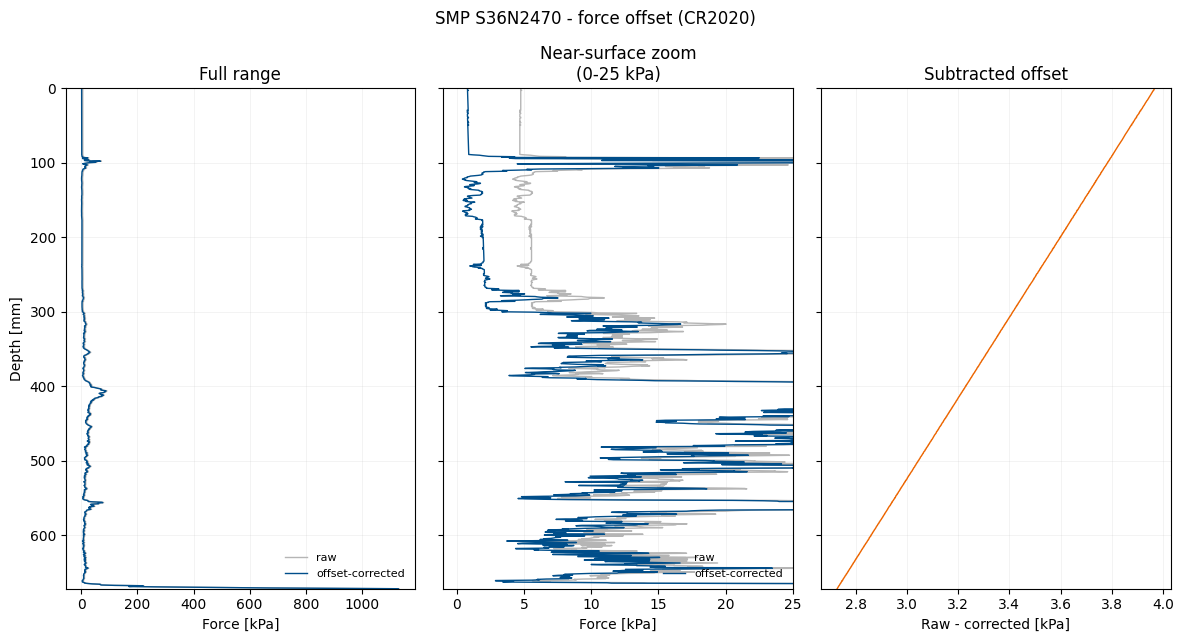

In [7]:
import matplotlib.pyplot as plt

smp_raw = SMPParser(str(PNT), density_method="CR2020", apply_drift_correction=False)
smp_corr = SMPParser(str(PNT), density_method="CR2020", apply_drift_correction=True)
prof_raw = smp_raw.extract_profile()
prof_corr = smp_corr.extract_profile()

offset = float(np.nanmedian(prof_raw.penetration_resistance_kPa - prof_corr.penetration_resistance_kPa))
print(f"median subtracted offset: {offset:.2f} kPa")

fig, (ax_full, ax_zoom, ax_diff) = plt.subplots(1, 3, figsize=(12, 6.5), sharey=True)

for ax in (ax_full, ax_zoom):
    ax.plot(prof_raw.penetration_resistance_kPa, prof_raw.depth_mm, color="#B5B5B5", lw=1.0, label="raw")
    ax.plot(
        prof_corr.penetration_resistance_kPa,
        prof_corr.depth_mm,
        color="#004E8A",
        lw=1.0,
        label="offset-corrected",
    )
    ax.set_xlabel("Penetration resistance [kPa]")

ax_full.set_ylabel("Depth [mm]")
ax_full.set_title("Full range")
ax_full.legend(loc="lower right", fontsize=8, frameon=False)

# Zoom the weak-signal window where a ~3 kPa offset actually shows.
ax_zoom.set_xlim(-1.0, 25.0)
ax_zoom.set_title("Near-surface zoom\n(0-25 kPa)")
ax_zoom.legend(loc="lower right", fontsize=8, frameon=False)

ax_diff.plot(
    prof_raw.penetration_resistance_kPa - prof_corr.penetration_resistance_kPa, prof_raw.depth_mm, color="#EC6500", lw=1.0
)
ax_diff.set_xlabel("Raw - corrected [kPa]")
ax_diff.set_title("Subtracted offset")

ax_full.set_ylim(float(np.nanmax(prof_raw.depth_mm)), float(prof_raw.depth_mm[0]))
for ax in (ax_full, ax_zoom, ax_diff):
    ax.grid(True, alpha=0.25, lw=0.4)
fig.suptitle("SMP S36N2470 - force offset (CR2020)")
fig.tight_layout()
plt.show()

# SnowScope (`.csv`)

The SnowScope parser reads penetration hardness (kPa) and derives density from a semilog model `D = a ln(F) + b` (default preset `HAGENMULLER2018`). Pass `semilog_slope` / `semilog_intercept` on the parser, on `extract_profile` / `extract_layers`, or on `plot_snowscope_penetration_parser` (or `plot_force_penetration_parser`) for site-specific calibrations (profile label `CUSTOM`). SnowScope profiles expose `penetration_resistance_kPa` like SMP, so the same four-panel plot helpers apply. This CSV is the co-located partner of the SMP profile above.


In [ ]:
scope = SnowScopeParser(str(CSV))
# Illustrative alternate calibration (custom semilog, not a shipped preset).
DEMO_SEMILOG_SLOPE = 50.0
DEMO_SEMILOG_INTERCEPT = 100.0
scope_custom = SnowScopeParser(
    str(CSV),
    semilog_slope=DEMO_SEMILOG_SLOPE,
    semilog_intercept=DEMO_SEMILOG_INTERCEPT,
)
scope_profile = scope.extract_profile()
scope_profile_custom = scope_custom.extract_profile()
scope_profile_oneoff = scope.extract_profile(
    semilog_slope=55.0,
    semilog_intercept=40.0,
)

print("samples     :", scope_profile.depth_mm.size)
print(
    "depth (mm)  : %.1f -> %.1f"
    % (scope_profile.depth_mm[0], scope_profile.depth_mm[-1])
)
print(
    "penetration resistance (kPa) : %.1f - %.1f"
    % (
        scope_profile.penetration_resistance_kPa.min(),
        scope_profile.penetration_resistance_kPa.max(),
    )
)
print(
    "density (HAGENMULLER2018) : %.1f - %.1f kg/m3"
    % (scope_profile.density_kg_m3.min(), scope_profile.density_kg_m3.max())
)
print("custom label  :", scope_profile_custom.density_method)
print(
    "custom density: %.0f - %.0f kg/m3"
    % (
        scope_profile_custom.density_kg_m3.min(),
        scope_profile_custom.density_kg_m3.max(),
    )
)
print("one-off label :", scope_profile_oneoff.density_method)
print(
    "one-off density: %.0f - %.0f kg/m3"
    % (
        scope_profile_oneoff.density_kg_m3.min(),
        scope_profile_oneoff.density_kg_m3.max(),
    )
)


samples     : 690
depth (mm)  : 1.0 -> 690.0
force (kPa) : 1.4 - 379.7
density     : 47.5 - 445.6 kg/m3


## Bin segmentation

SnowScope bin 20 mm -> 35 layers


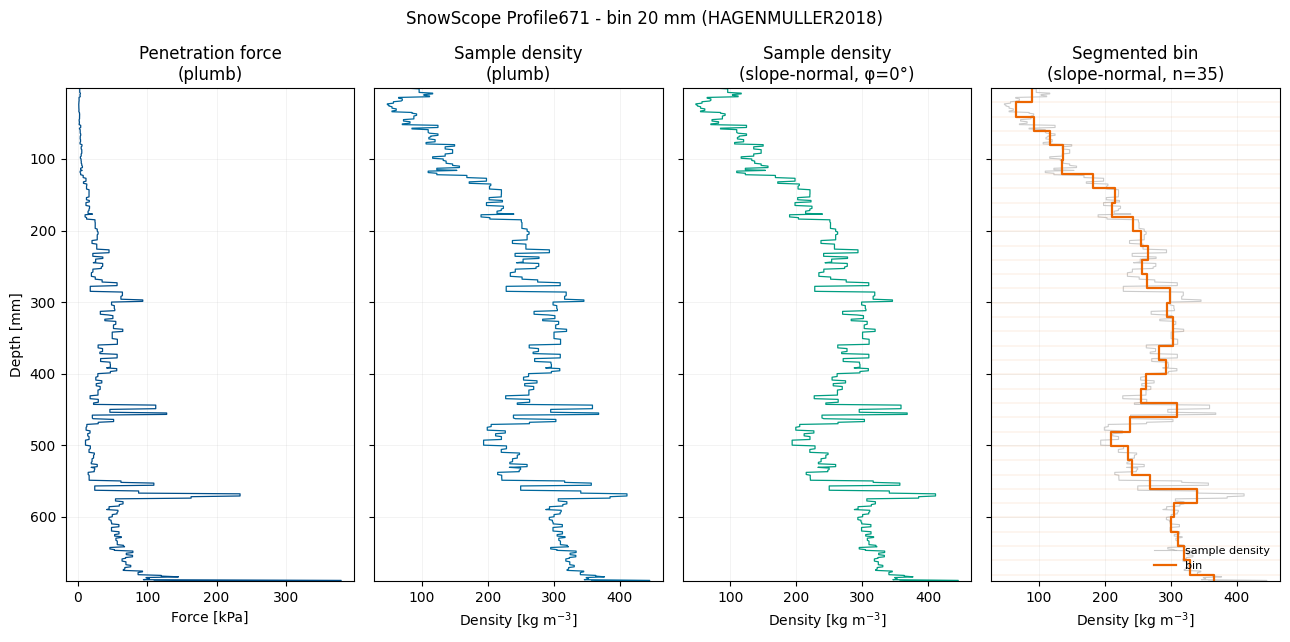

In [9]:
scope_bin, _ = scope.extract_layers(method="bin", layer_thickness_mm=20.0)
print(f"SnowScope bin 20 mm -> {len(scope_bin)} layers")
fig = plot_snowscope_penetration_parser(
    scope,
    method="bin",
    layer_thickness_mm=20.0,
    title="SnowScope Profile671 - bin 20 mm (HAGENMULLER2018)",
    show=False,
)


In [ ]:
# Same panels with custom semilog on the plot call (constructor default unchanged).
fig = plot_force_penetration_parser(
    scope,
    method="bin",
    layer_thickness_mm=20.0,
    semilog_slope=DEMO_SEMILOG_SLOPE,
    semilog_intercept=DEMO_SEMILOG_INTERCEPT,
    title="SnowScope Profile671 - bin 20 mm (custom semilog demo)",
    show=False,
)


## Gradient segmentation

SnowScope gradient T=12 -> 1 layers


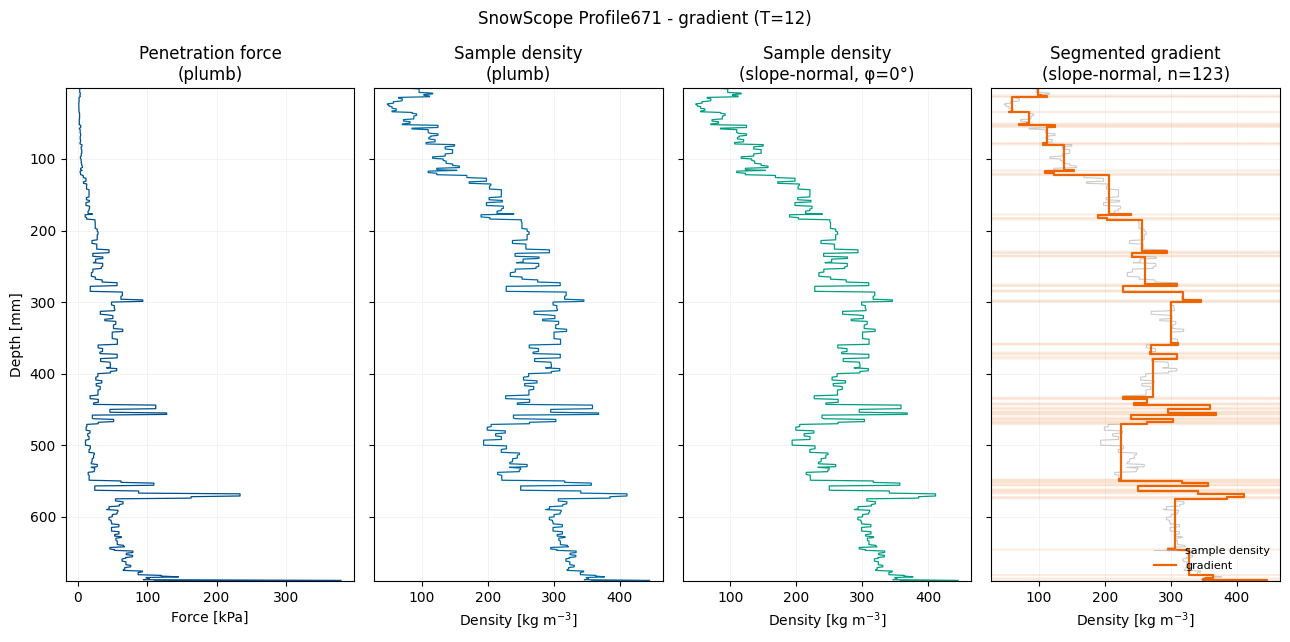

In [ ]:
scope_grad, _ = scope.extract_layers(method="gradient", gradient_threshold=12.0)
print(f"SnowScope gradient T=12 -> {len(scope_grad)} layers")
fig = plot_force_penetration_parser(
    scope,
    method="gradient",
    gradient_threshold=12.0,
    title="SnowScope Profile671 - gradient (T=12)",
    show=False,
)

## Plotting an existing profile + layers

`plot_force_penetration_parser` is a convenience wrapper. If you already hold a profile and layers, call `plot_force_penetration_layers` directly - pass the same `slope_angle_deg` you used to extract the layers so the slope-normal panels match.

n layers: 35 | first: rho=89 h=20.0


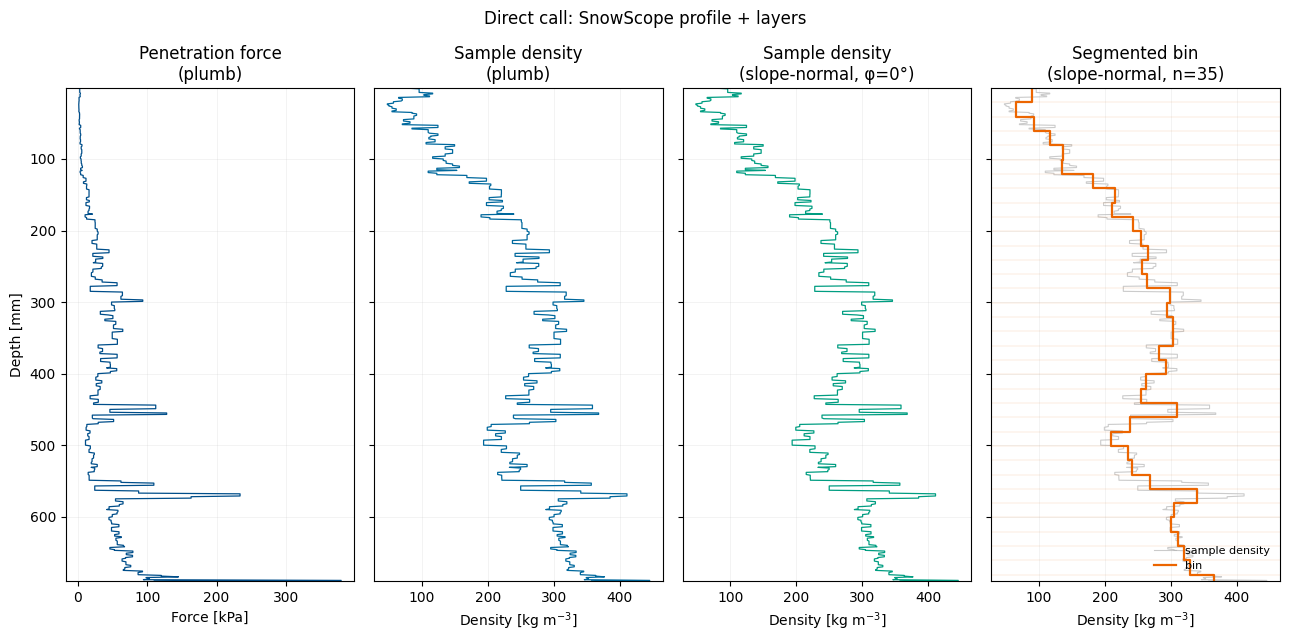

In [11]:
layers, _ = scope.extract_layers(method="bin", layer_thickness_mm=20.0)
print(
    "n layers:",
    len(layers),
    "| first:",
    "rho=%.0f h=%.1f" % (layers[0].rho, layers[0].h),
)
fig = plot_force_penetration_layers(
    scope_profile,
    layers,
    layer_label="bin",
    title="Direct call: SnowScope profile + layers",
    show=False,
)

# Overlay: all three sources

`demo/data/` now holds a third, co-located profile: the SnowPilot **CAAML** (`.xml`) export of the same Weissfluhjoch pit (its notes reference the same SnowScope runs 669-679). The three parsers report layers on different vertical grids - the probes emit fixed `bin`/`gradient` slabs, SnowPilot emits hand-hardness/observation layers - but all are ordered surface -> ground with slope-normal `Layer.h`.

We overlay the reconstructed density-vs-depth staircases on one axis, each anchored at the snow surface (depth 0, increasing downward), so the layering from the three instruments can be compared directly despite differing total snow heights.

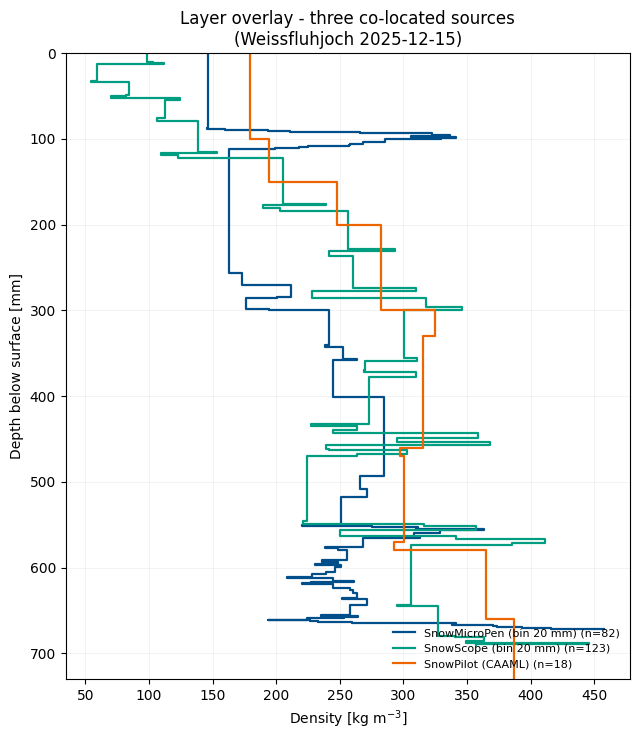

In [12]:
import matplotlib.pyplot as plt

XML = DATA / "Profile-35ace732-eb53-4f85-aa48-4a964c0d6877.xml"
pilot = SnowPilotParser(str(XML))

# Layers surface -> ground from each source (gradient).
smp_layers, _ = smp.extract_layers(method="gradient")
scope_layers, _ = scope.extract_layers(method="gradient")
pilot_layers, _ = pilot.extract_layers()


def staircase(layers):
    """Density-vs-depth staircase anchored at the surface (depth 0, downward)."""
    import numpy as np

    h = np.array([layer.h for layer in layers], float)
    rho = np.repeat([layer.rho for layer in layers], 2)
    bottoms = np.cumsum(h)
    tops = np.concatenate(([0.0], bottoms[:-1]))
    depth = np.empty(rho.size)
    depth[0::2] = tops
    depth[1::2] = bottoms
    return rho, depth


sources = [
    ("SnowMicroPen (bin 20 mm)", smp_layers, "#004E8A"),
    ("SnowScope (bin 20 mm)", scope_layers, "#009D81"),
    ("SnowPilot (CAAML)", pilot_layers, "#EC6500"),
]

fig, ax = plt.subplots(figsize=(6.5, 7.5))
max_depth = 0.0
for label, layers, color in sources:
    rho, depth = staircase(layers)
    max_depth = max(max_depth, float(depth[-1]))
    ax.plot(rho, depth, color=color, lw=1.6, label=f"{label} (n={len(layers)})")

ax.set_xlabel("Density [kg m$^{-3}$]")
ax.set_ylabel("Depth below surface [mm]")
ax.set_title("Layer overlay - three co-located sources\n(Weissfluhjoch 2025-12-15)")
ax.set_ylim(max_depth, 0.0)
ax.grid(True, alpha=0.25, lw=0.4)
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

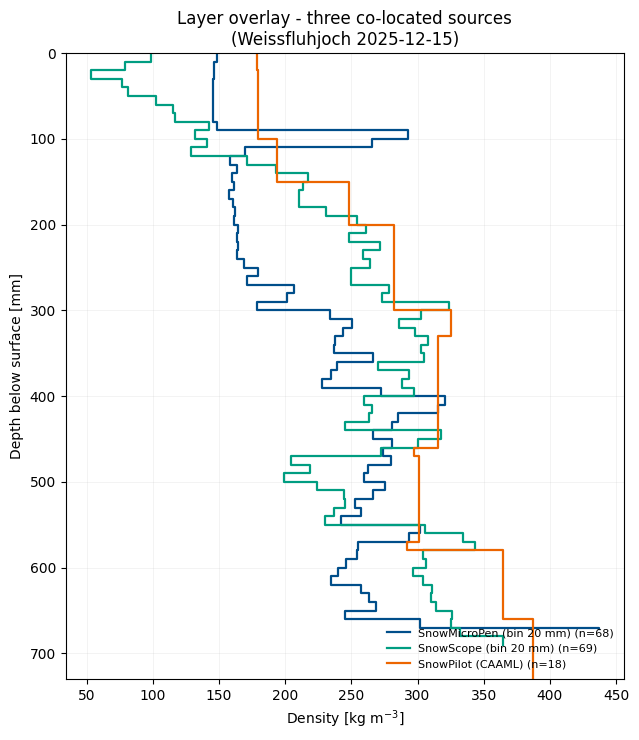

In [13]:
import matplotlib.pyplot as plt

smp_layers, _ = smp.extract_layers(method="bin", layer_thickness_mm=10)
scope_layers, _ = scope.extract_layers(method="bin", layer_thickness_mm=10)


def staircase(layers):
    """Density-vs-depth staircase anchored at the surface (depth 0, downward)."""
    import numpy as np

    h = np.array([layer.h for layer in layers], float)
    rho = np.repeat([layer.rho for layer in layers], 2)
    bottoms = np.cumsum(h)
    tops = np.concatenate(([0.0], bottoms[:-1]))
    depth = np.empty(rho.size)
    depth[0::2] = tops
    depth[1::2] = bottoms
    return rho, depth


sources = [
    ("SnowMicroPen (bin 20 mm)", smp_layers, "#004E8A"),
    ("SnowScope (bin 20 mm)", scope_layers, "#009D81"),
    ("SnowPilot (CAAML)", pilot_layers, "#EC6500"),
]

fig, ax = plt.subplots(figsize=(6.5, 7.5))
max_depth = 0.0
for label, layers, color in sources:
    rho, depth = staircase(layers)
    max_depth = max(max_depth, float(depth[-1]))
    ax.plot(rho, depth, color=color, lw=1.6, label=f"{label} (n={len(layers)})")

ax.set_xlabel("Density [kg m$^{-3}$]")
ax.set_ylabel("Depth below surface [mm]")
ax.set_title("Layer overlay - three co-located sources\n(Weissfluhjoch 2025-12-15)")
ax.set_ylim(max_depth, 0.0)
ax.grid(True, alpha=0.25, lw=0.4)
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()